# Winograd convolution

So, the english is not very good, I will improve that

In [225]:
import itertools

import sympy as sy
import numpy as np

In [226]:
import fitz
from PIL import Image
from IPython.display import display, YouTubeVideo

In [227]:
doc = fitz.open('/home/tarsio/zotero-lib/AUTH/Blahut/Blahut_2010_Fast algorithms for signal processing.pdf')

In [228]:
def plot_pdf(page, crop_float=None,  dpi=200,):
    """
    (upper, lower)
    crop float value between 0 and 1
    """
    pix = page.get_pixmap(dpi=dpi)
    # mode = "RGBA" if pix.alpha else "RGB"
    mode = "RGB"
    image = Image.frombytes(mode, [pix.width, pix.height], pix.samples)
    if crop_float is None:
        display(image)
    else:
        assert 0 <= crop_float[0] <= 1
        assert 0 <= crop_float[1] <= 1
        # assert 0 <= crop_float[2] <= 1
        # assert 0 <= crop_float[3] <= 1
        left = 0
        upper = int(pix.height * crop_float[0])
        right = pix.width
        lower = int(pix.height * crop_float[1])
        crop = (left, upper, right, lower)
        display(image.crop(crop))

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from Youtube.

In this tutorial I will quote the theoretical first and the example after that for best understanding.

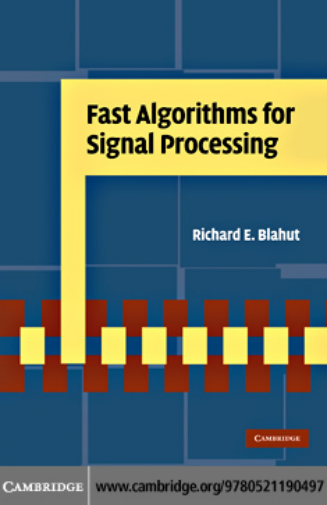

In [229]:
plot_pdf(doc[0], dpi=100)

## Polynomials

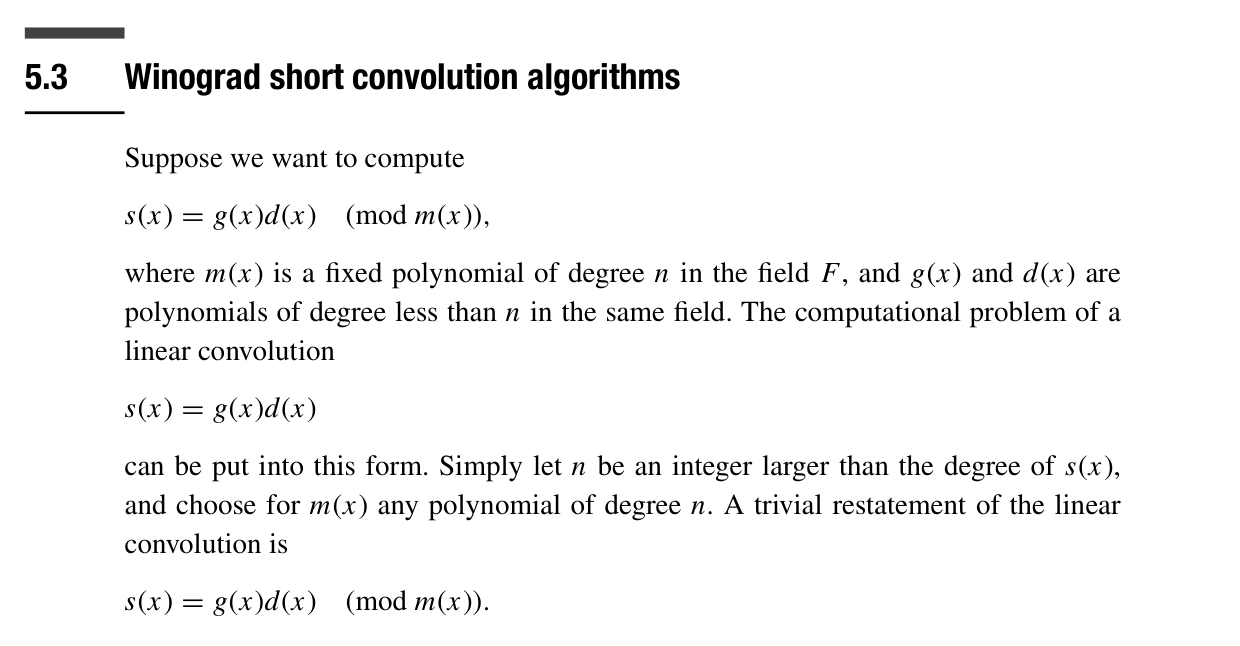

In [230]:
plot_pdf(doc[170], [.55, .89])

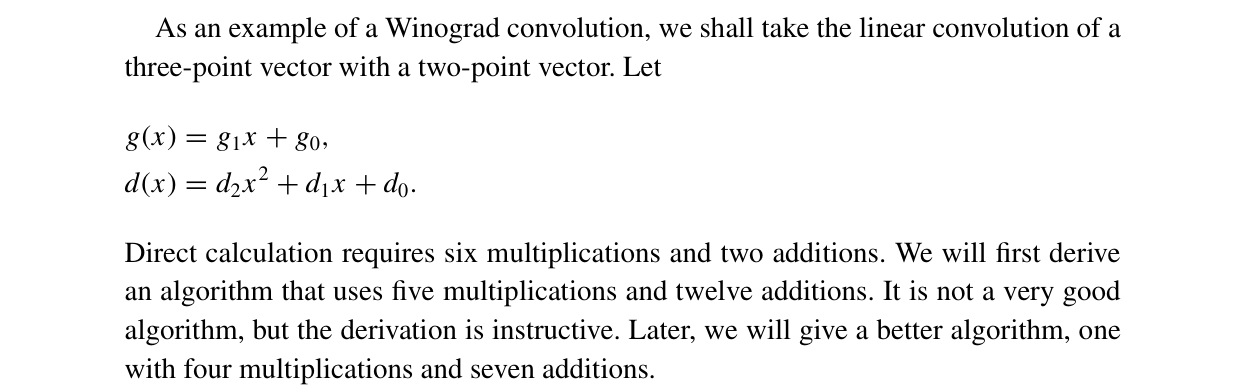

In [231]:
plot_pdf(doc[174], [.25, .455])

Size of vectors

In [232]:
d_num = 3
g_num = 2

Example of vectors for the convolution

In [233]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2]


Polynomial degree

In [234]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 1


In [235]:
x = sy.symbols("x")
x

x

In [236]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2]])

In [237]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [238]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2

In [239]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [240]:
sx = gx*dx
sx

(g_0 + g_1*x)*(d_0 + d_1*x + d_2*x**2)

## Factor

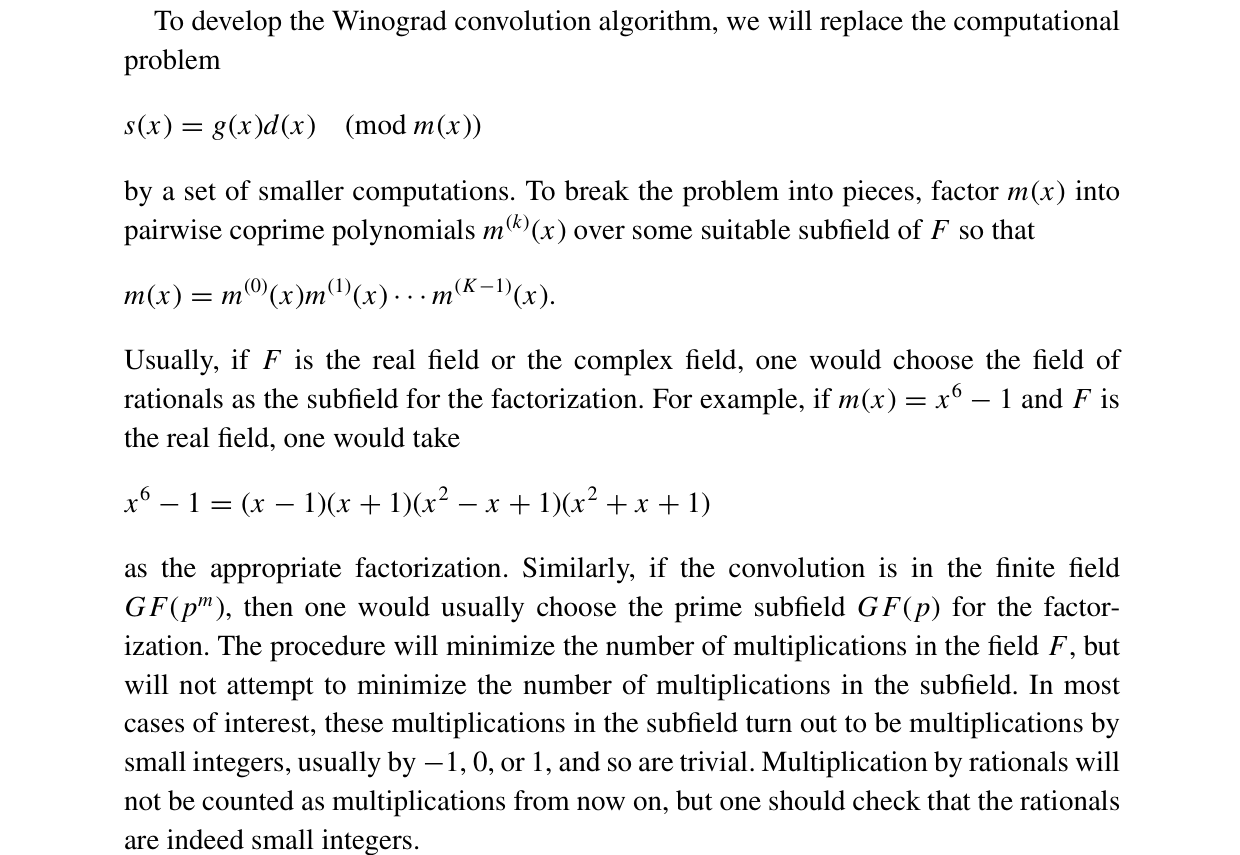

In [241]:
plot_pdf(doc[171], [0.2, 0.65])

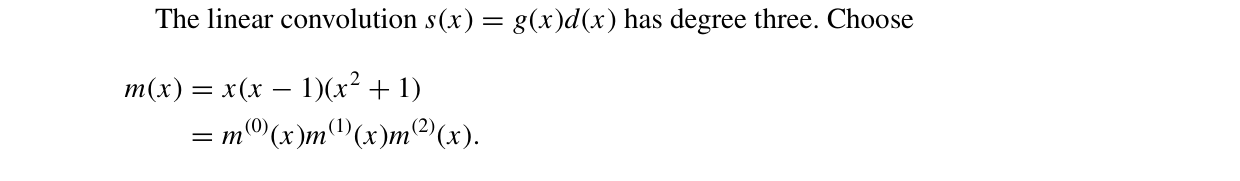

In [242]:
plot_pdf(doc[174], [.455, .55])

In [243]:
mk = sy.Matrix([x, x-1, x**2+1])
mk

Matrix([
[       x],
[   x - 1],
[x**2 + 1]])

## Remainders of input polynomials

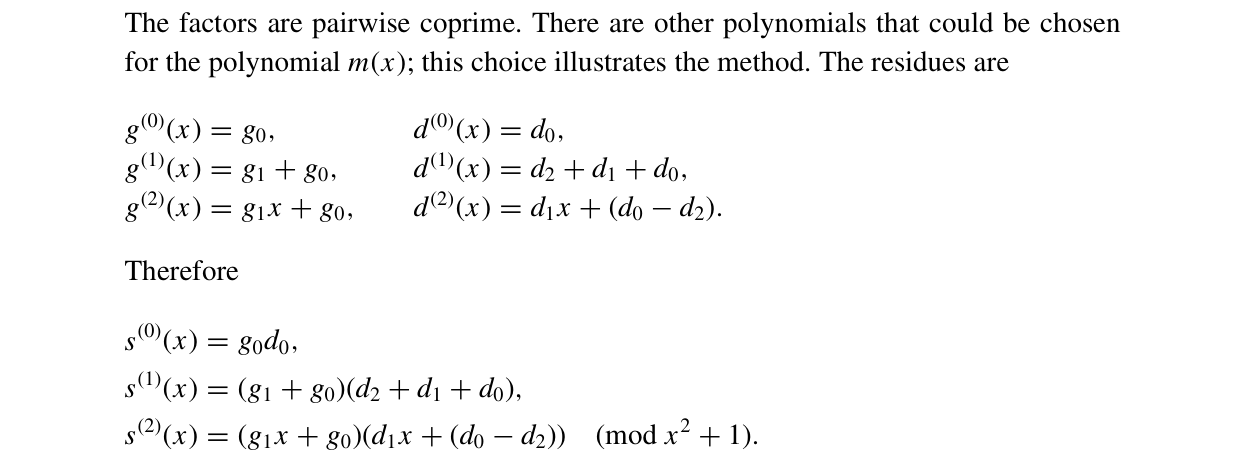

In [244]:
plot_pdf(doc[174], [.55, .8])

$d_k$ and $g_k$ pass by a polynomial division and we only get the remainder

In [245]:
gk = sy.Matrix([sy.rem(gx, q, domain ='ZZ') for q in mk])
gk

Matrix([
[        g_0],
[  g_0 + g_1],
[g_0 + g_1*x]])

In [246]:
dk = sy.Matrix([sy.rem(dx, q, domain ='ZZ') for q in mk])
dk

Matrix([
[              d_0],
[  d_0 + d_1 + d_2],
[d_0 + d_1*x - d_2]])

## $S^2$ 

$S^2$ development is different, and i don't understand this part yet.

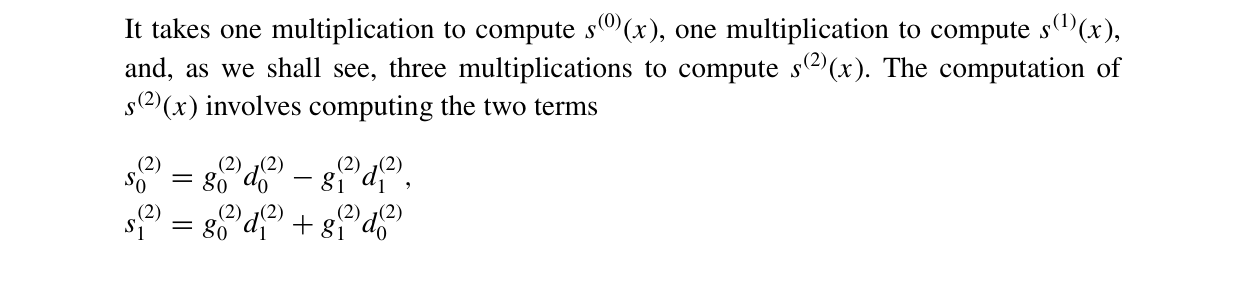

In [247]:
plot_pdf(doc[174], [.8, .95])

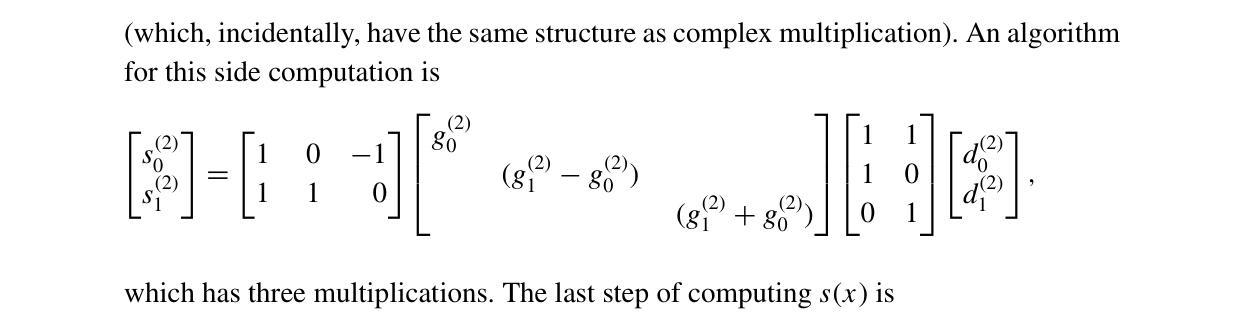

In [248]:
plot_pdf(doc[175], [.27, .44])

Just defining values of matrices

In [249]:
a2_mtx = sy.Matrix([[1, 1], [1, 0], [0, 1]])
a2_mtx

Matrix([
[1, 1],
[1, 0],
[0, 1]])

In [250]:
b2_mtx = sy.Matrix([[1, 0], [-1, 1], [1, 1]])
b2_mtx

Matrix([
[ 1, 0],
[-1, 1],
[ 1, 1]])

In [251]:
c2_mtx = sy.Matrix([
    [1, 0, -1],
    [1, 1, 0],
])
c2_mtx

Matrix([
[1, 0, -1],
[1, 1,  0]])

## Remainders of (output) inverse polynomial

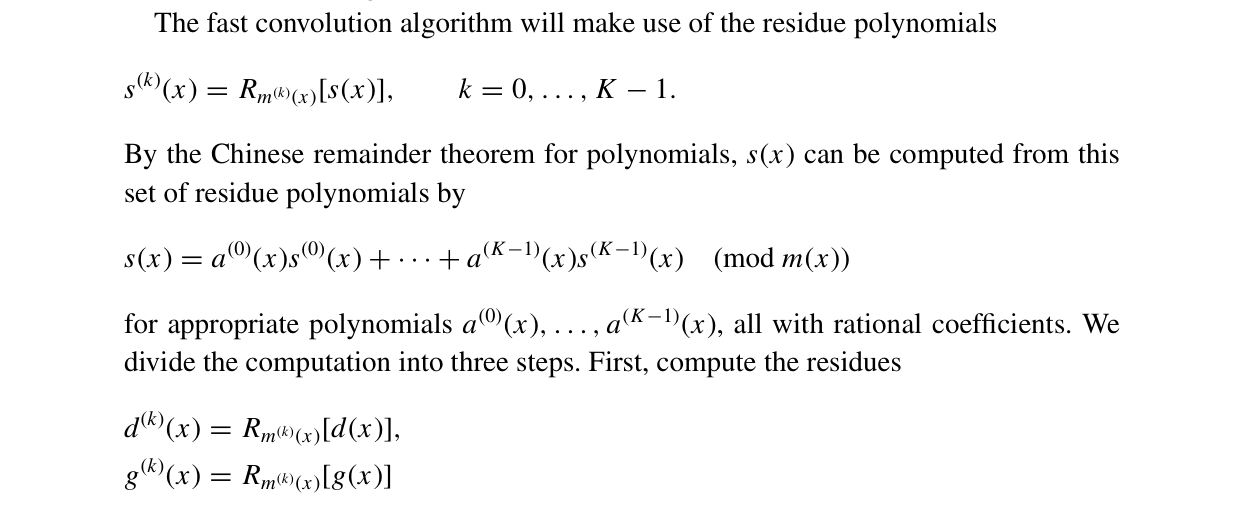

In [252]:
plot_pdf(doc[171], [0.65, .92])

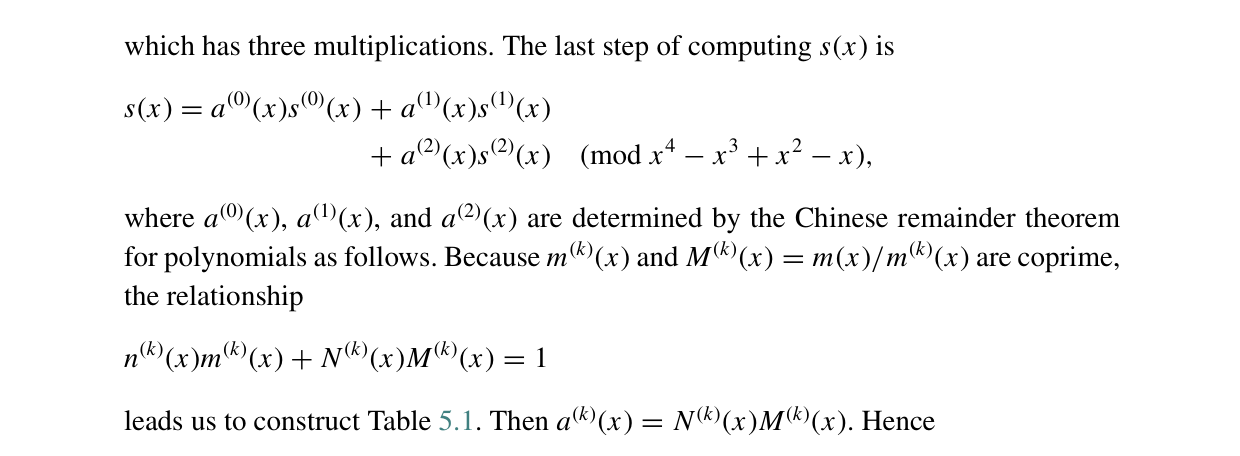

In [253]:
plot_pdf(doc[175], [.4, .64])

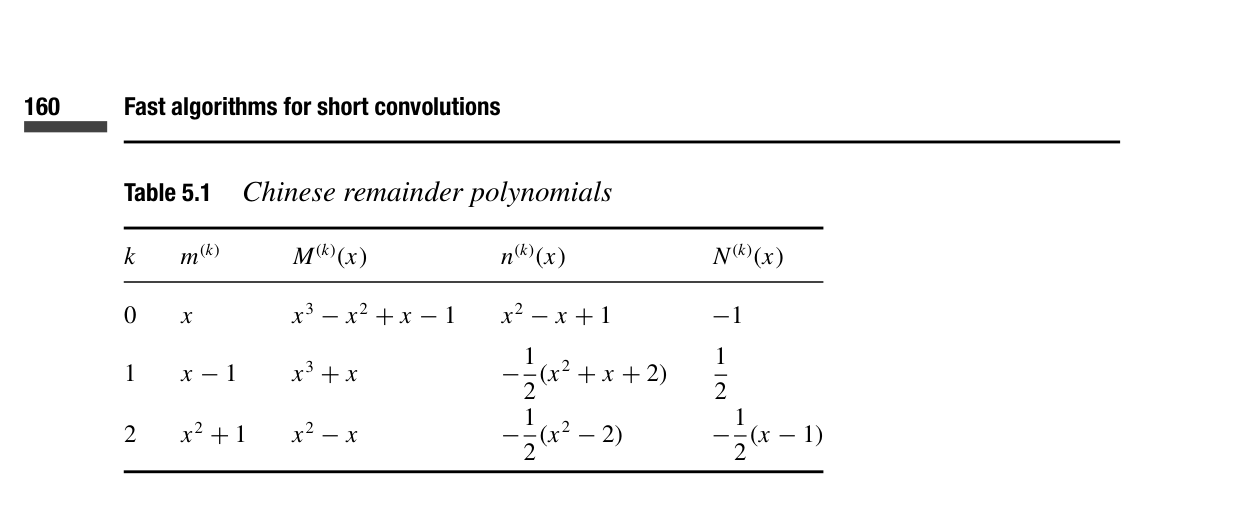

In [254]:
plot_pdf(doc[175], [0, .27])

$m^{(k)}$ is `mk`
 
$M^{(k)}$ is `mmk`
 
$N^{(k)}$ is `nnk`

In [255]:
mk

Matrix([
[       x],
[   x - 1],
[x**2 + 1]])

In [256]:
mmk = sy.Matrix([sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)])
mmk

Matrix([
[x**3 - x**2 + x - 1],
[           x**3 + x],
[           x**2 - x]])

Pegando quociente e resto, agora tem q colocar no formato nm+NM=1

In [257]:
mmk_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]

In [258]:
mmk_quo = sy.Matrix([x[0] for x in mmk_div])
mmk_quo

Matrix([
[x**2 - x + 1],
[x**2 + x + 2],
[           1]])

In [259]:
mmk_rem = sy.Matrix([x[1] for x in mmk_div])
mmk_rem

Matrix([
[    -1],
[     2],
[-x - 1]])

Here we see the first differences or problems to replicate the examples from book, $n^{(2)}$ and $N^{(2)}$ are different.

In [260]:
nnk = sy.Matrix([1/z for z in mmk_rem])
nnk

Matrix([
[        -1],
[       1/2],
[1/(-x - 1)]])

In the video above the teacher first divide $m^{(2)}$ by the remainder $r^{(2)}$ of $M^{(2)}$ by $m^{(2)}$, after that she gets this result and divide the quotient $q_{mr^{(2)}}$ by the remainder $r_{mr^{(2)}}$. if the variable $x$ is negative then is multiplicated by $-1$. This is the correct $N^{(2)}$.

The $n^{(2)}$ is the quotient $q_{mr^{(2)}}$ of of $M^{(2)}$ by $m^{(2)}$ by the remainder $r_{mr^{(2)}}$.

Explain better

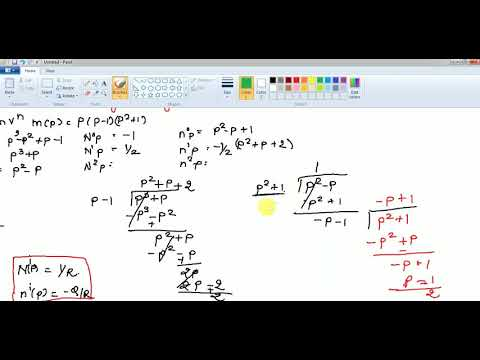

In [261]:
# https://youtu.be/VYohQWIcwpQ?si=lc--gl9KR-liBuX4&t=340
YouTubeVideo('VYohQWIcwpQ', width=400*2, height=300*2, start=340)

In [262]:
mmk2_quo, mmk2_rem = sy.div(mk[-1], mmk_rem[-1], domain ='ZZ')

In [263]:
mmk2_quo

1 - x

In [264]:
mmk2_rem

2

If nnk has x coefficient, this need to be positive

In [265]:
nnk2 = mmk2_quo/mmk2_rem
nnk2 = nnk2*(-1) if nnk2.coeff(x).is_negative else nnk2
nnk2

x/2 - 1/2

In [266]:
nk2 = (mmk_quo[-1] + nnk2)
nk2

x/2 + 1/2

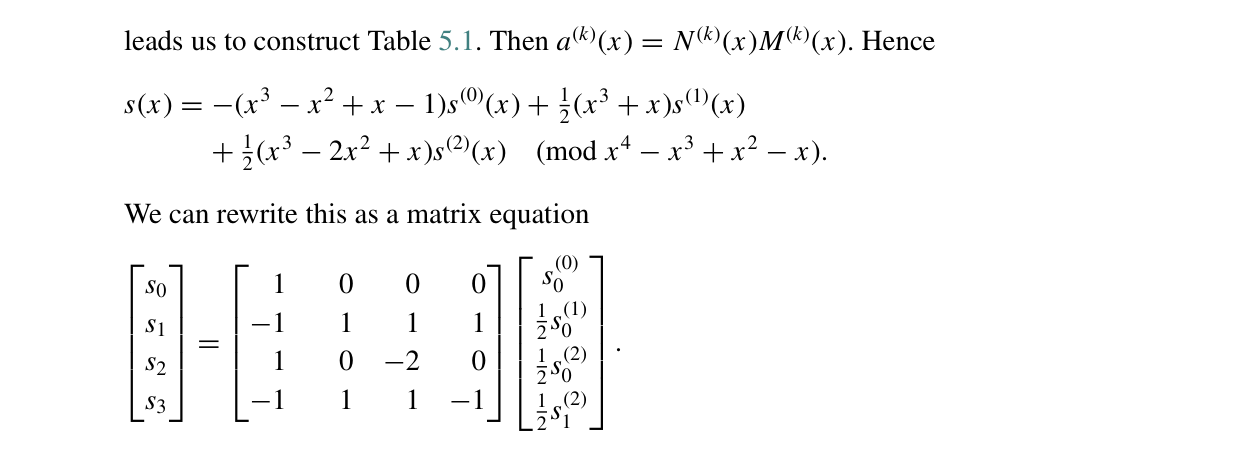

In [267]:
plot_pdf(doc[175], [0.6, .84])

In the next video $S^{(2)} = M^{(2)} \times N^{(2)}$

$S^{(2)} = S_{0}^{(2)} + S_{1}^{(2)}x$

And $S_{1}^{(2)}$ is the remainder of $M(x)$ by $S_{1}^{(2)}x$


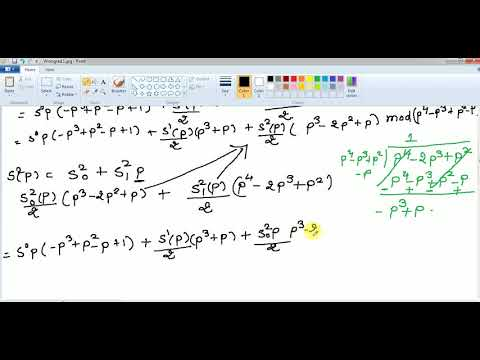

In [268]:
YouTubeVideo('Dkh4bsCLb4M', width=400*2, height=300*2)

I don't multiply the  M^{(2)} by N^{(2)}$ but by the quotient of $m^{(2)}$
by (mmk_rem[-1] | mmk, mk)

In [269]:
c20_mtx = sy.expand(mmk[-1]*mmk2_quo)
c20_mtx

-x**3 + 2*x**2 - x

In [270]:
c21_mtx = sy.rem(np.prod(mk), sy.expand(c20_mtx*x), domain ='QQ')
c21_mtx

x**3 - x

## Put all together

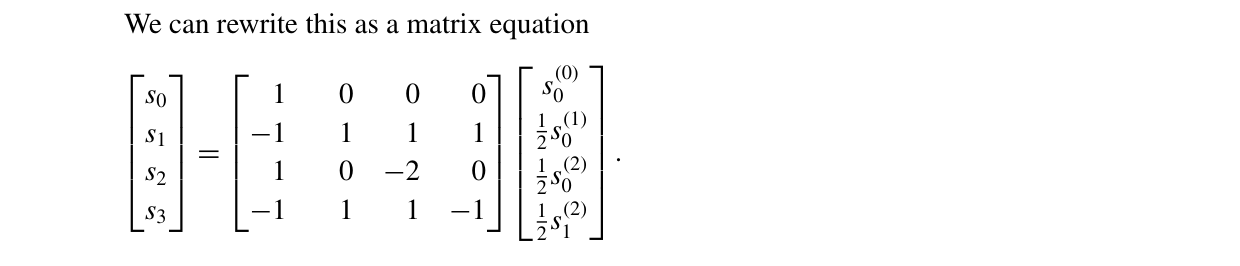

In [300]:
plot_pdf(doc[175], [0.7, .84])

Important: the signals of the $C$ matrix are inverted.
I multiply $N^{(k)}$ matrix by $G$ and not by $C$.
In books the constants of $N^{(k)}$ go to $G$, and the signals go to $C$.
In this implementation all go to $G$.

In [297]:
c_lst = [[d.coeff(x, c) for d in mmk[:-1] + [c20_mtx] + [c21_mtx]] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)]
c_lst

[[-1, 0, 0, 0], [1, 1, -1, -1], [-1, 0, 2, 0], [1, 1, -1, 1]]

In [298]:
c0_mtx = sy.Matrix(c_lst)
c0_mtx

Matrix([
[-1, 0,  0,  0],
[ 1, 1, -1, -1],
[-1, 0,  2,  0],
[ 1, 1, -1,  1]])

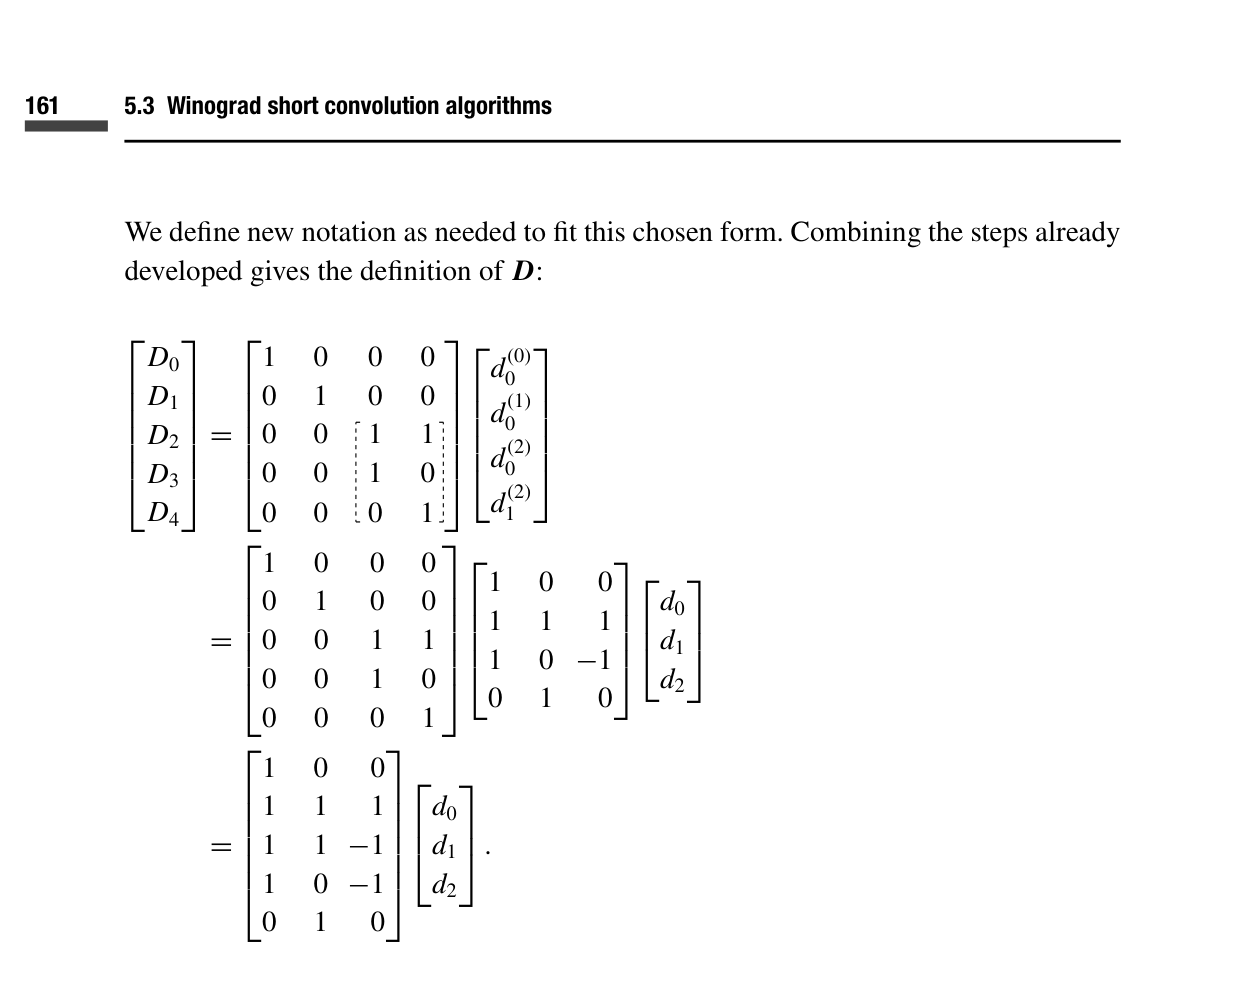

In [304]:
plot_pdf(doc[176], [0, .52])

In [271]:
a0_lst = [[d.coeff(c, 1) for c in di] for d in dk[:-1]]
a0_lst

[[1, 0, 0], [1, 1, 1]]

In [272]:
a20_lst = [dk[-1].subs({x:0}).coeff(c, 1) for c in di]
a20_lst

[1, 0, -1]

In [273]:
a21_lst = [sy.div(dk[-1], c, domain ='QQ')[0].subs({x:1}) for c in di]
a21_lst

[0, 1, 0]

In [274]:
a0_mtx = sy.Matrix(np.vstack([a0_lst, a20_lst, a21_lst]))
a0_mtx

Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 0, -1],
[0, 1,  0]])

In [275]:
a2_mtx = sy.Matrix(sy.diag(sy.eye(2), a2_mtx))
a2_mtx

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 1],
[0, 0, 1, 0],
[0, 0, 0, 1]])

In [276]:
a_mtx = a2_mtx * a0_mtx
a_mtx

Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])

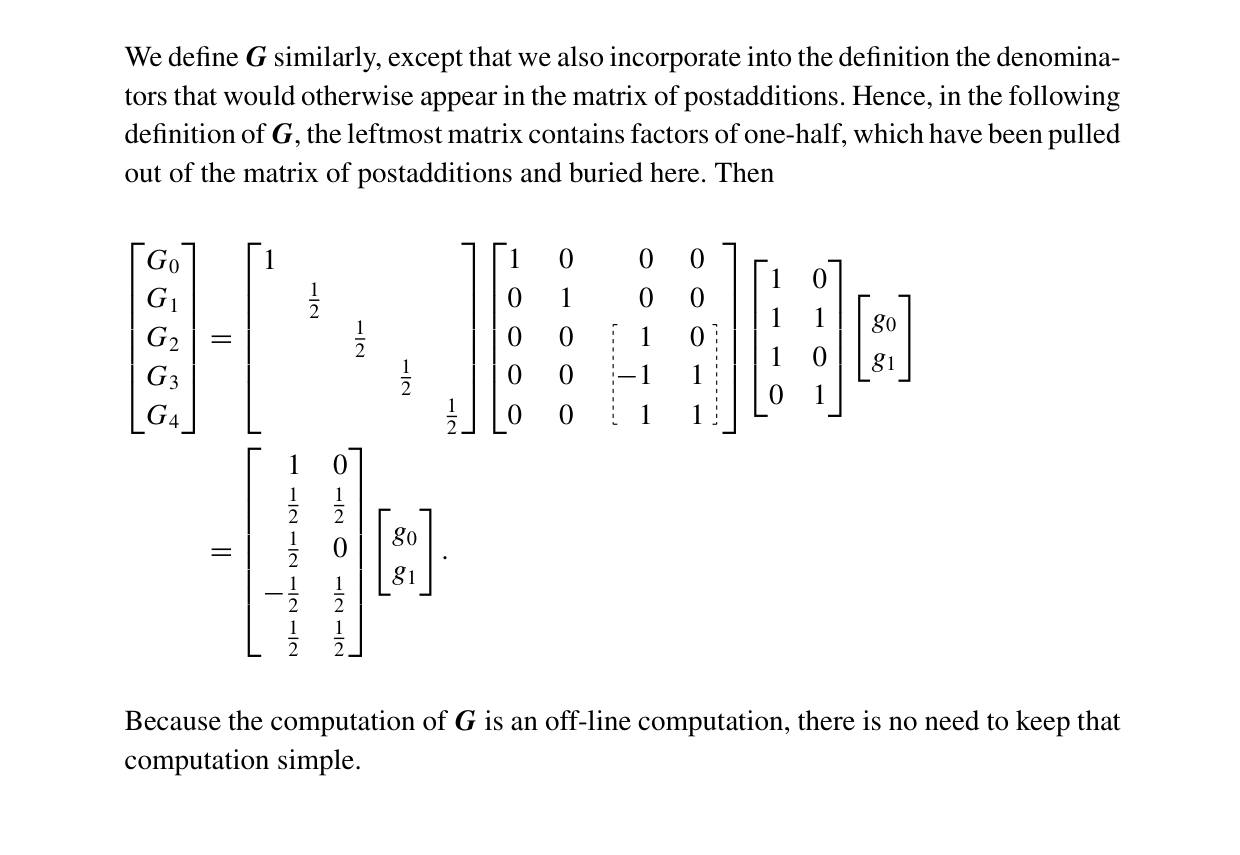

In [308]:
plot_pdf(doc[176], [.5, .95])

In [277]:
b0_lst = [[g.coeff(c, 1) for c in gi] for g in gk[:-1]]
b0_lst

[[1, 0], [1, 1]]

In [278]:
b20_lst = [gk[-1].subs({x:0}).coeff(c, 1) for c in gi]
b20_lst

[1, 0]

In [279]:
b21_lst = [sy.div(gk[-1], c, domain ='QQ')[0].subs({x:1}) for c in gi]
b21_lst

[0, 1]

In [280]:
b0_mtx = sy.Matrix(np.vstack([b0_lst, b20_lst, b21_lst]))
b0_mtx


Matrix([
[1, 0],
[1, 1],
[1, 0],
[0, 1]])

In [281]:
b2_mtx = sy.Matrix(sy.diag(sy.eye(2), b2_mtx))
b2_mtx

Matrix([
[1, 0,  0, 0],
[0, 1,  0, 0],
[0, 0,  1, 0],
[0, 0, -1, 1],
[0, 0,  1, 1]])

In [282]:
b_mtx = b2_mtx * b0_mtx
b_mtx


Matrix([
[ 1, 0],
[ 1, 1],
[ 1, 0],
[-1, 1],
[ 1, 1]])

Multiplicar o resto pela matriz G depois
O sinal negativo vai pra matriz G e não pra C


In [283]:
g_mtx = sy.diag(*(nnk[:-1] + [nnk2.subs({x:0})]*(d_num+g_num - len(nnk[:-1]))))
g_mtx

Matrix([
[-1,   0,    0,    0,    0],
[ 0, 1/2,    0,    0,    0],
[ 0,   0, -1/2,    0,    0],
[ 0,   0,    0, -1/2,    0],
[ 0,   0,    0,    0, -1/2]])

In [284]:
bg_mtx = sy.diag(*(g_mtx*b_mtx*sy.Matrix(gi)).tolist())
bg_mtx

Matrix([
[-g_0,             0,      0,             0,              0],
[   0, g_0/2 + g_1/2,      0,             0,              0],
[   0,             0, -g_0/2,             0,              0],
[   0,             0,      0, g_0/2 - g_1/2,              0],
[   0,             0,      0,             0, -g_0/2 - g_1/2]])

In [285]:
nk = [q*r*(-1) for q, r in zip(mmk_quo[:-1], nnk[:-1])] + [nnk2]
sy.Matrix(nk)

Matrix([
[     x**2 - x + 1],
[-x**2/2 - x/2 - 1],
[        x/2 - 1/2]])

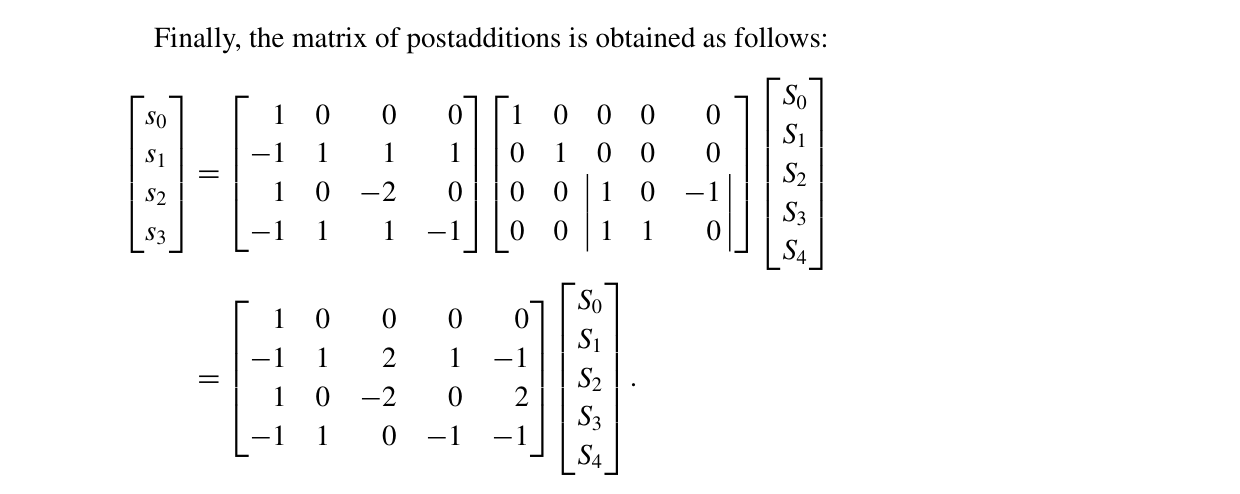

In [318]:
plot_pdf(doc[177], [.36, .62])

In [288]:
c2_mtx = sy.Matrix(sy.diag(sy.eye(2), c2_mtx))
c2_mtx

Matrix([
[1, 0, 0, 0,  0],
[0, 1, 0, 0,  0],
[0, 0, 1, 0, -1],
[0, 0, 1, 1,  0]])

In [289]:
c_mtx = c0_mtx * c2_mtx
c_mtx

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])

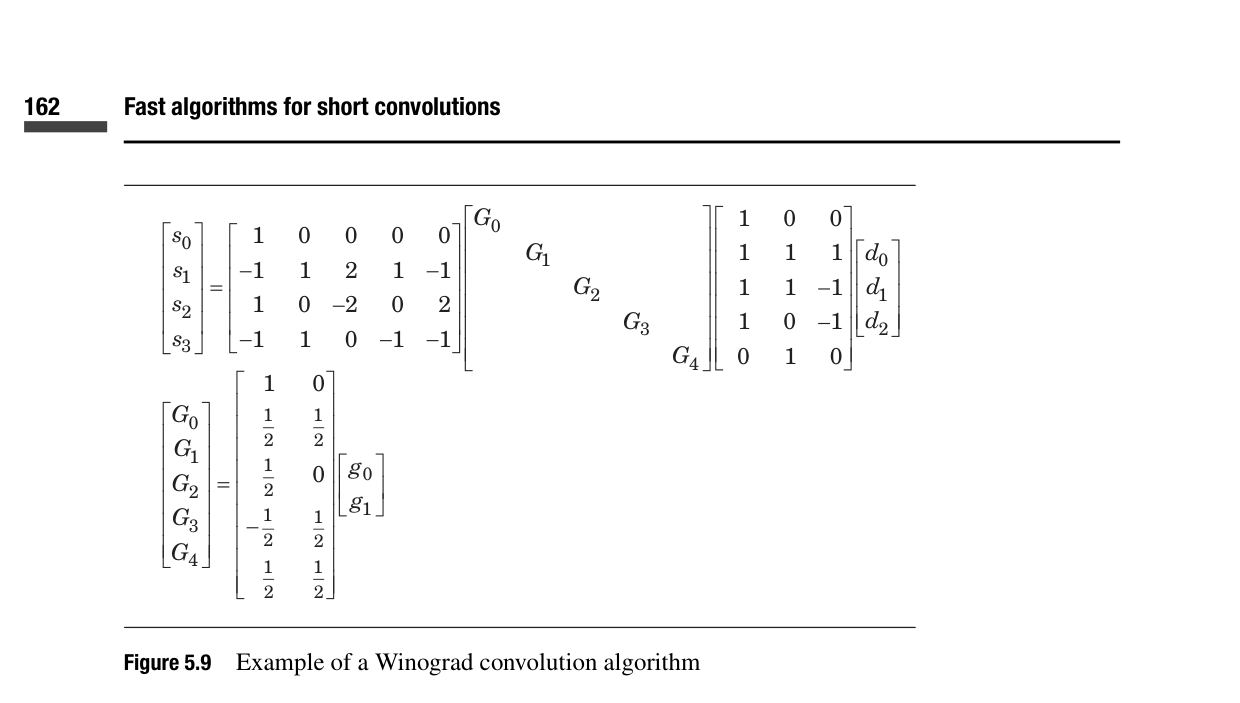

In [320]:
plot_pdf(doc[177], [0, .37])

In [290]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])*Matrix([
[-g_0,             0,      0,             0,              0],
[   0, g_0/2 + g_1/2,      0,             0,              0],
[   0,             0, -g_0/2,             0,              0],
[   0,             0,      0, g_0/2 - g_1/2,              0],
[   0,             0,      0,             0, -g_0/2 - g_1/2]])*Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])*Matrix([
[d_0],
[d_1],
[d_2]])

## Example

In [291]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d_0: 1, d_1: 2, d_2: 3, g_0: 1, g_1: 2}

In [292]:
si = s.subs(subs)
si

Matrix([
[-1, 0,  0,  0,  0],
[ 1, 1, -2, -1,  1],
[-1, 0,  2,  0, -2],
[ 1, 1,  0,  1,  1]])*Matrix([
[-1,   0,    0,    0,    0],
[ 0, 3/2,    0,    0,    0],
[ 0,   0, -1/2,    0,    0],
[ 0,   0,    0, -1/2,    0],
[ 0,   0,    0,    0, -3/2]])*Matrix([
[1, 0,  0],
[1, 1,  1],
[1, 1, -1],
[1, 0, -1],
[0, 1,  0]])*Matrix([
[1],
[2],
[3]])

In [293]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_1*g_0*x + d_1*g_1*x**2 + d_2*g_0*x**2 + d_2*g_1*x**3

In [294]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[d_1*g_1 + d_2*g_0],
[          d_2*g_1]])

In [295]:
out = np.convolve(d_values, g_values)
print(out)

[1 4 7 6]


In [296]:
se.subs(subs)

Matrix([
[1],
[4],
[7],
[6]])